In [1]:
import pickle
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Autoencoder, SirenNet
from minf.utils import plot_field
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [2]:
resolution = 16

df = pd.read_csv("../data/drug_central.csv")

smiles = df["smiles"].tolist()

fd = FieldDataset(smiles, resolution=resolution)
dl = DataLoader(fd, batch_size=4, shuffle=True)
dl_test = DataLoader(fd, batch_size=8, shuffle=False)

In [3]:
net = SirenNet(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=8,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

autoencoder = Autoencoder(
    net,
    in_channels=10,
    output_shape=[resolution, resolution, resolution, 10, 1],
    latent_dim=256,
)

autoencoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=autoencoder.parameters())

# Load the model
autoencoder.load_state_dict(torch.load("../models/drug_central.pt", weights_only=True))
autoencoder.cuda()

/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Autoencoder(
  (net): SirenNet(
    (layers): ModuleList(
      (0-7): 8 x Siren(
        (activation): Sine()
      )
    )
    (last_layer): Siren(
      (activation): Identity()
    )
  )
  (encoder): Encoder(
    (in_layer): Conv3d(10, 20, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_input): BatchNorm3d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (layer_1): Conv3d(20, 40, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_1): BatchNorm3d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (out_layer): Conv3d(40, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_output): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pooling): AdaptiveAvgPool3d(output_size=1)
  )
  (modulator): Modulator(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): ReLU()
      )
      

[22:49:53] UFFTYPER: Warning: hybridization set to SP3 for atom 1                                            | 5/513 [00:02<03:48,  2.23it/s]
[22:49:53] UFFTYPER: Unrecognized charge state for atom: 1
[22:50:05] UFFTYPER: Warning: hybridization set to SP3 for atom 1                                           | 21/513 [00:13<04:37,  1.77it/s]
[22:50:05] UFFTYPER: Unrecognized charge state for atom: 1
[22:50:05] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[22:50:05] UFFTYPER: Unrecognized charge state for atom: 4
  5%|█████                                                                                                  | 25/513 [00:19<08:35,  1.06s/it]

200


[22:50:11] UFFTYPER: Unrecognized atom type: Ti1+4 (1)                                                      | 28/513 [00:20<04:34,  1.77it/s]
[22:50:11] UFFTYPER: Unrecognized atom type: Zn+2 (1)
[22:50:11] UFFTYPER: Warning: hybridization set to SP3 for atom 1
[22:52:05] UFFTYPER: Unrecognized charge state for atom: 1                                                  | 42/513 [02:14<23:50,  3.04s/it]
[22:52:05] UFFTYPER: Unrecognized atom type: S_6+6 (1)                                                      | 45/513 [02:14<15:11,  1.95s/it]
 11%|██████████▊                                                                                            | 54/513 [02:15<04:43,  1.62it/s]

400


[22:52:06] UFFTYPER: Unrecognized charge state for atom: 1                                                  | 57/513 [02:15<03:21,  2.27it/s]
 15%|███████████████▋                                                                                       | 78/513 [02:16<00:35, 12.26it/s]

...

[22:52:24] UFFTYPER: Unrecognized charge state for atom: 11                                                | 206/513 [02:33<00:57,  5.33it/s]
 44%|████████████████████████████████████████████▋                                                         | 225/513 [02:37<00:52,  5.49it/s]

1800


 49%|█████████████████████████████████████████████████▋                                                    | 250/513 [02:42<00:53,  4.90it/s]

2000


[22:52:33] UFFTYPER: Unrecognized charge state for atom: 1                                                 | 252/513 [02:42<00:57,  4.57it/s]
 49%|██████████████████████████████████████████████████▎                                                   | 253/513 [02:57<03:02,  1.43it/s]


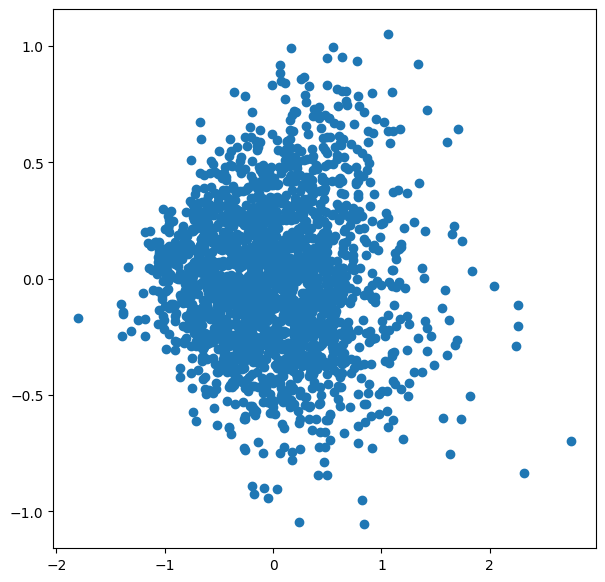

In [4]:
x = []
for batch in tqdm(dl_test, total=len(dl_test)):
    latents = autoencoder.encode(batch.cuda())
    for latent in latents:
        x.append(latent.cpu().detach().numpy())
    if len(x) % 100 == 0:
        print(len(x))

x_pc = PCA(n_components=2).fit_transform(x)

fig, ax = plt.subplots(figsize=(7, 7))

# for i, coord in enumerate(x_pc):
#     ax.text(coord[0], 
#             coord[1], 
#             str(y[i]), fontsize=18)

ax.scatter(x_pc.T[0], x_pc.T[1])

0


[22:53:50] WARNING: not removing hydrogen atom without neighbors


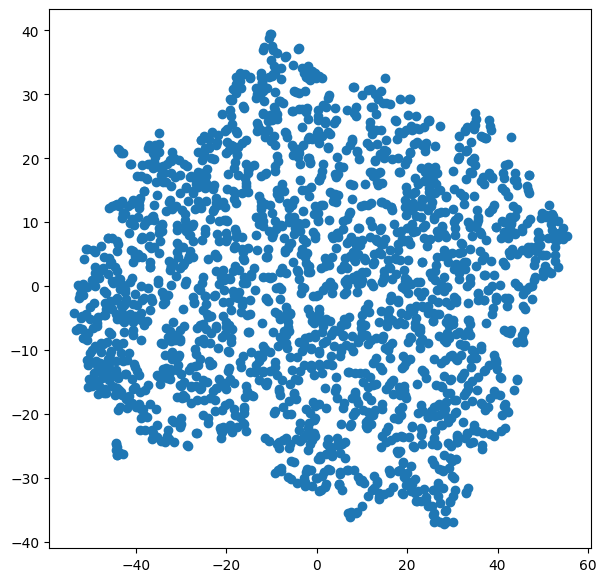

1


[22:53:52] WARNING: not removing hydrogen atom without neighbors


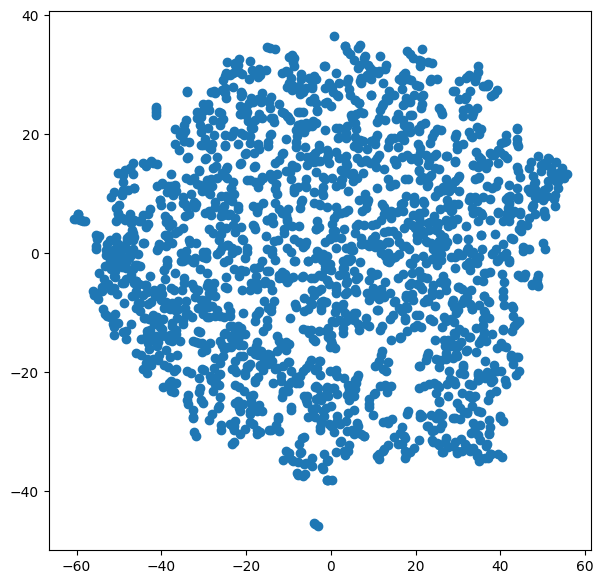

2


[22:53:54] WARNING: not removing hydrogen atom without neighbors


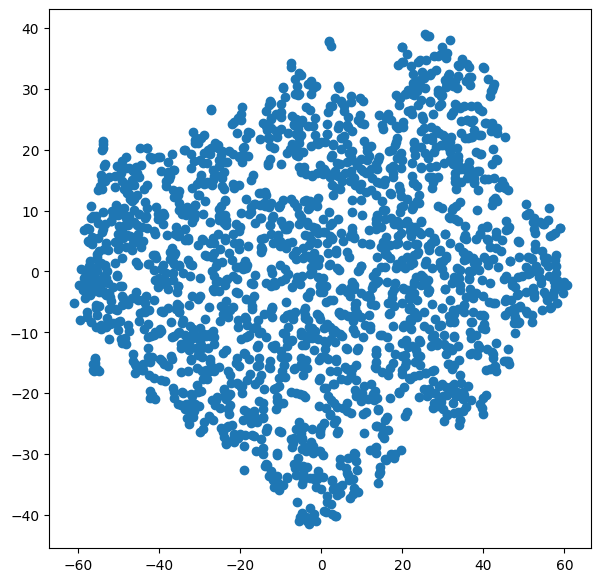

3


[22:53:56] WARNING: not removing hydrogen atom without neighbors


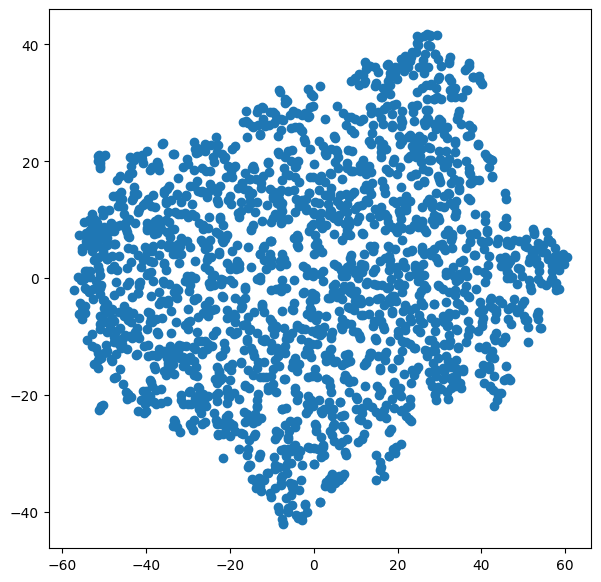

4


[22:53:58] WARNING: not removing hydrogen atom without neighbors


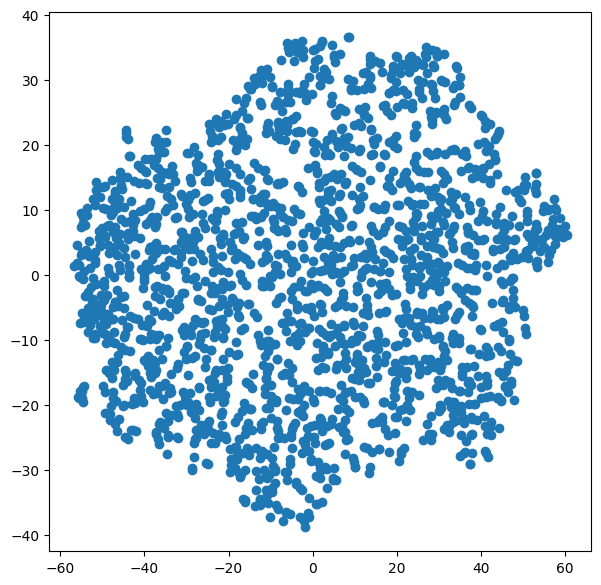

5


[22:54:00] WARNING: not removing hydrogen atom without neighbors


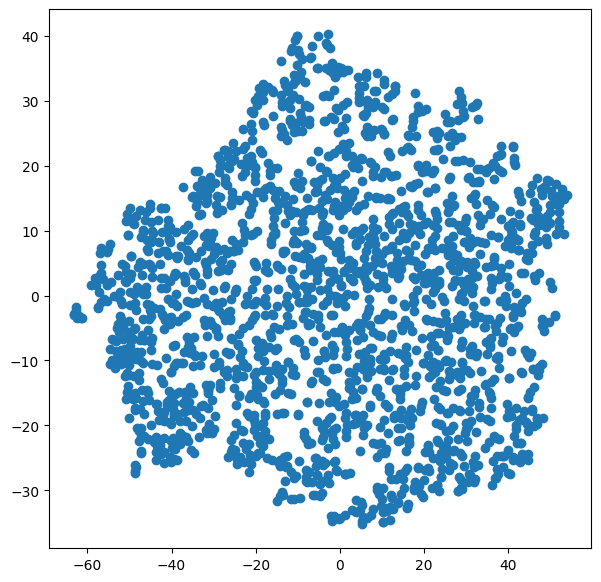

6


[22:54:01] WARNING: not removing hydrogen atom without neighbors


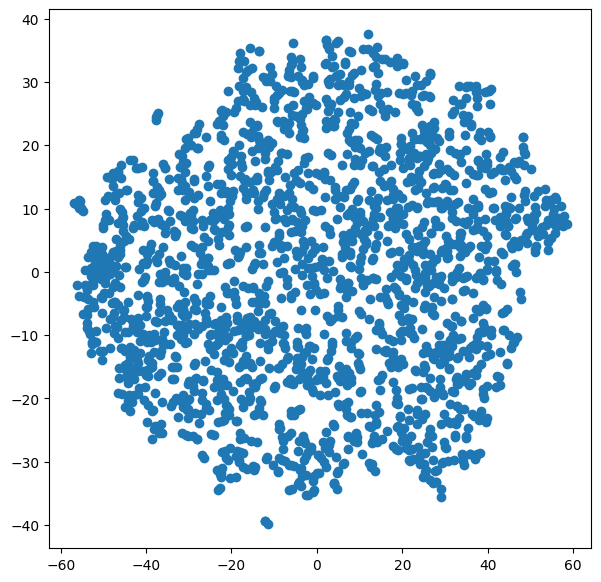

7


[22:54:03] WARNING: not removing hydrogen atom without neighbors


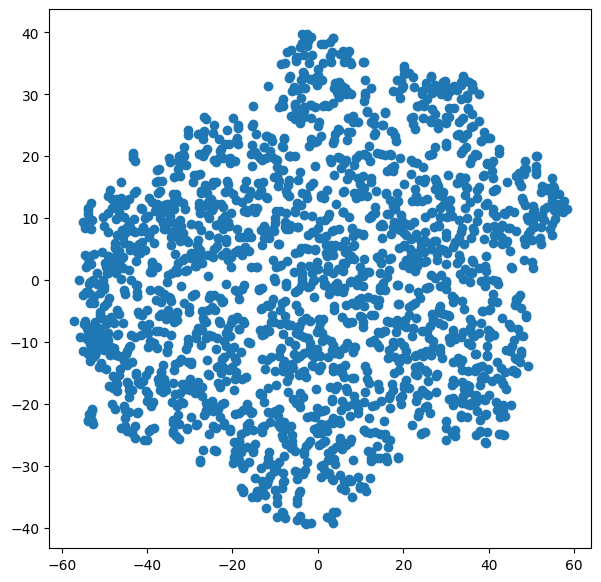

8


[22:54:05] WARNING: not removing hydrogen atom without neighbors


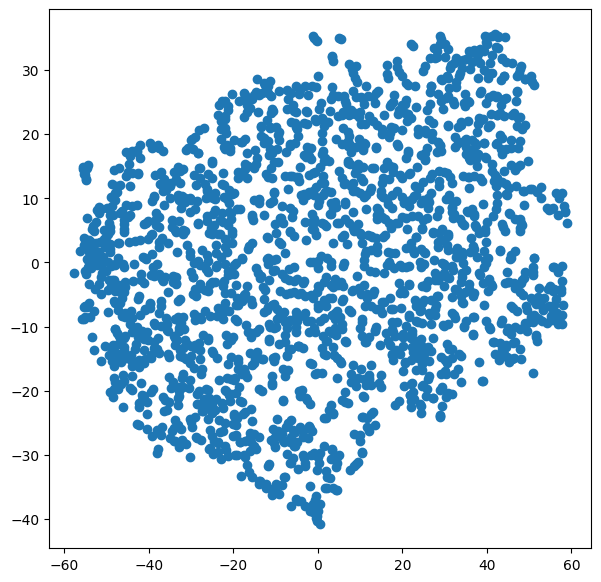

9


[22:54:08] WARNING: not removing hydrogen atom without neighbors


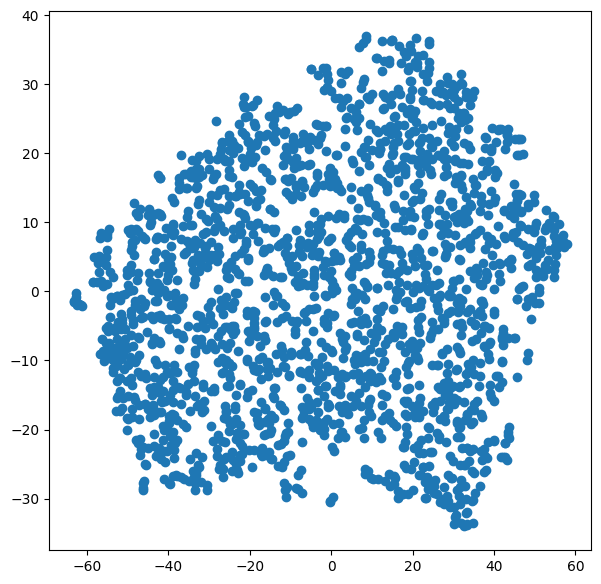

10


[22:54:10] WARNING: not removing hydrogen atom without neighbors


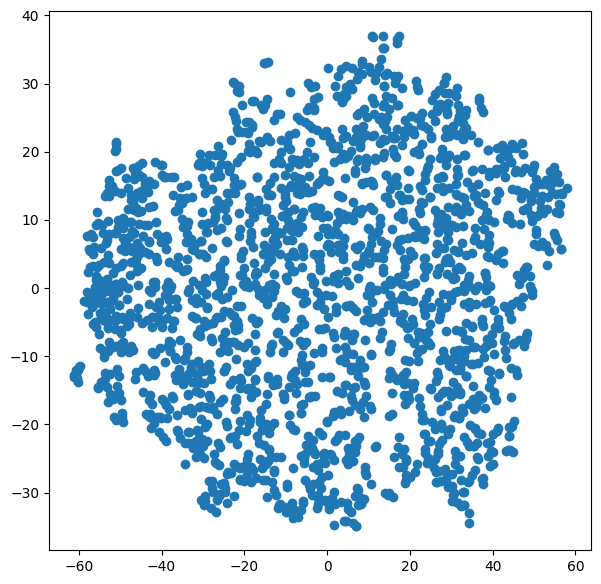

11


[22:54:12] WARNING: not removing hydrogen atom without neighbors


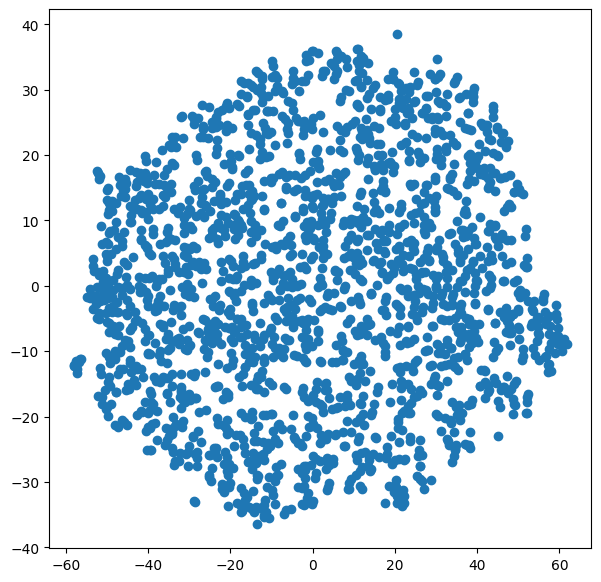

12


[22:54:14] WARNING: not removing hydrogen atom without neighbors


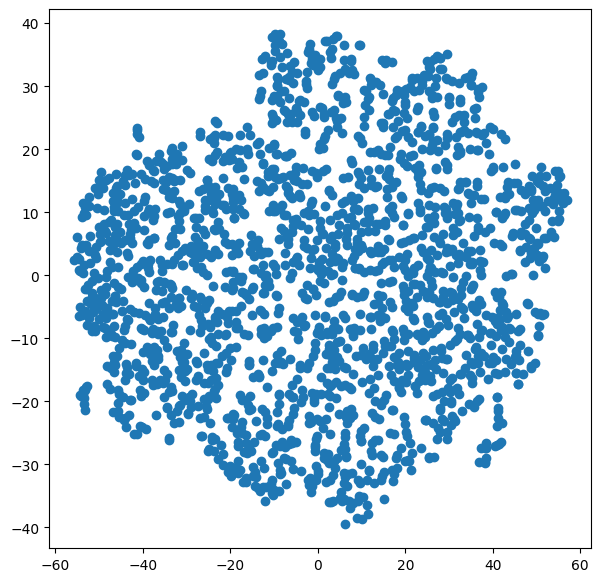

13


[22:54:16] WARNING: not removing hydrogen atom without neighbors


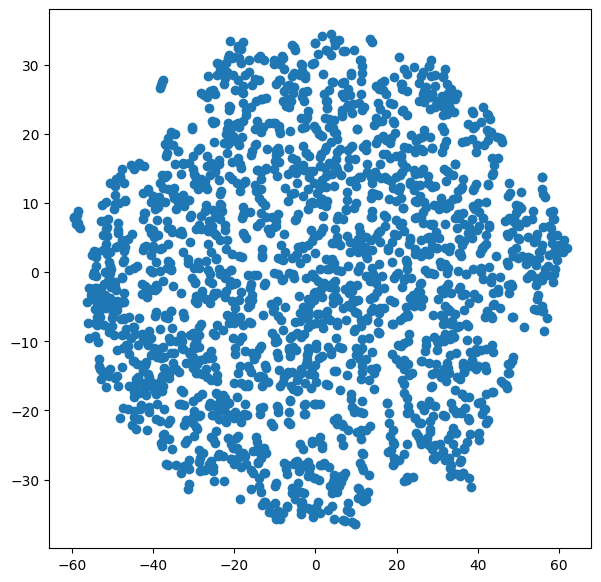

14


[22:54:18] WARNING: not removing hydrogen atom without neighbors


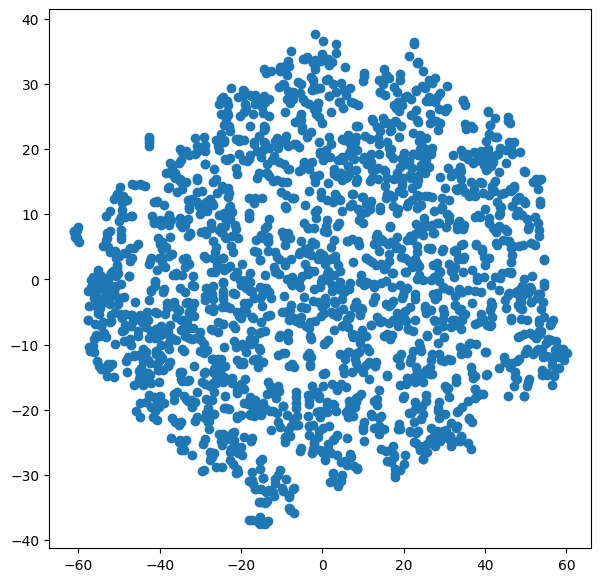

15


[22:54:20] WARNING: not removing hydrogen atom without neighbors


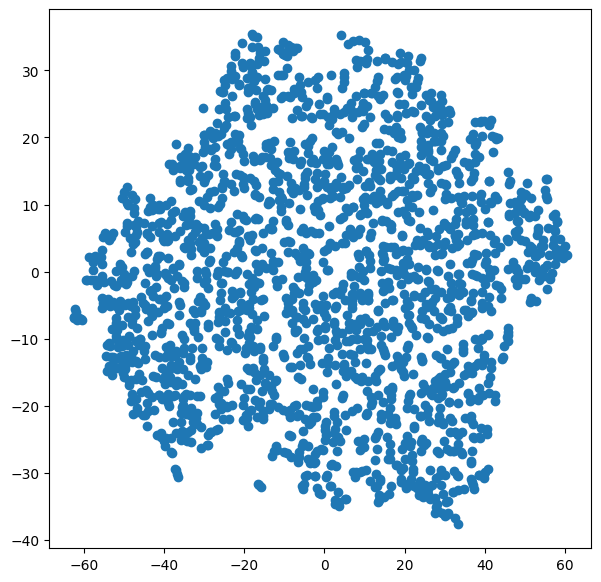

16


[22:54:22] WARNING: not removing hydrogen atom without neighbors


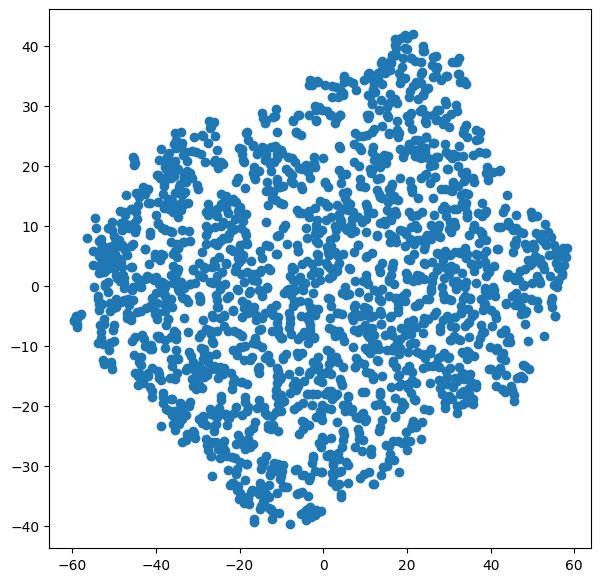

17


[22:54:24] WARNING: not removing hydrogen atom without neighbors


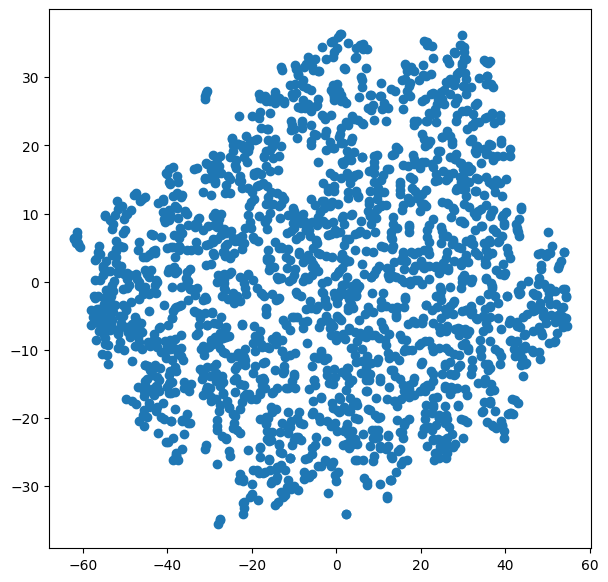

18


[22:54:26] WARNING: not removing hydrogen atom without neighbors


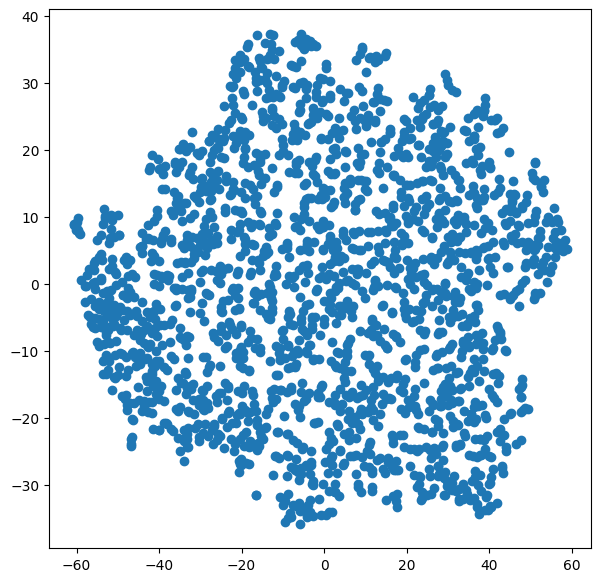

19


[22:54:28] WARNING: not removing hydrogen atom without neighbors


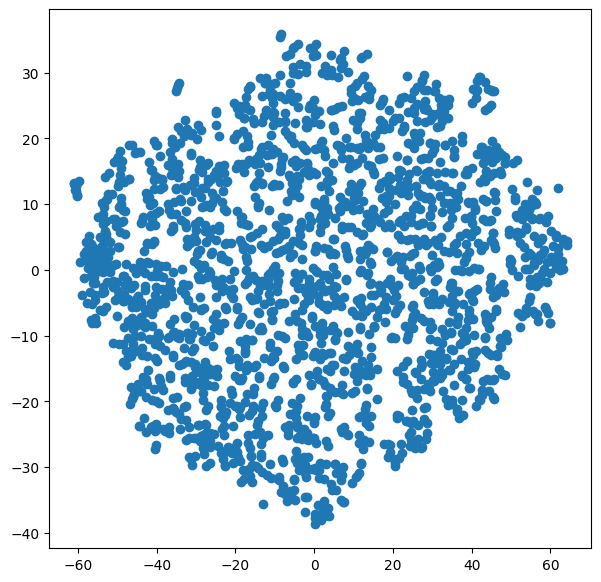

20


[22:54:30] WARNING: not removing hydrogen atom without neighbors


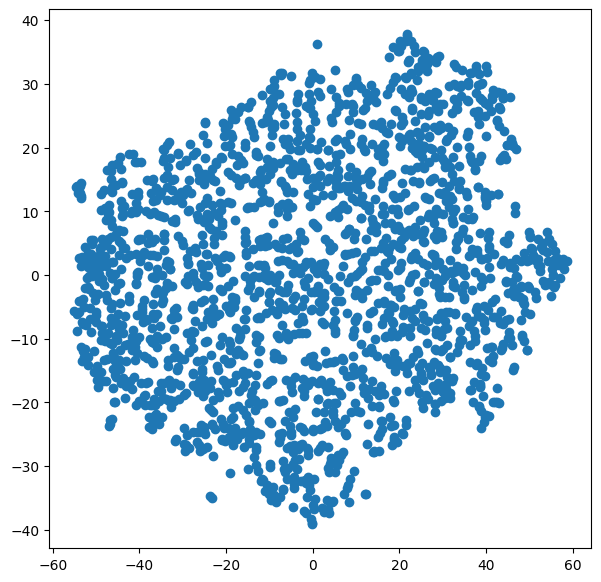

21


[22:54:32] WARNING: not removing hydrogen atom without neighbors


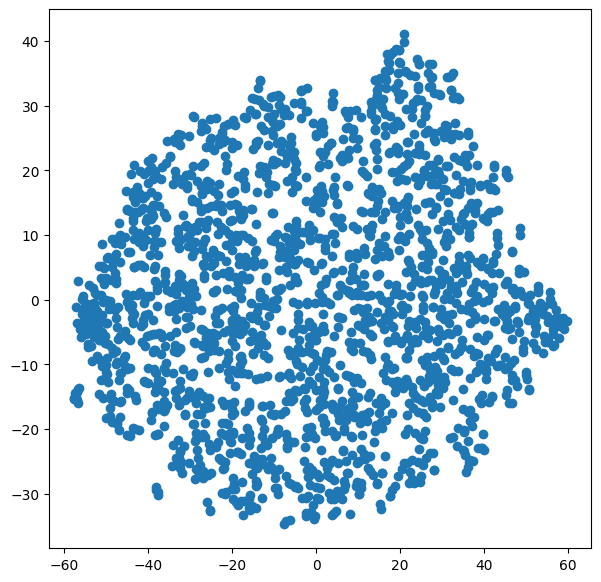

22


[22:54:34] WARNING: not removing hydrogen atom without neighbors


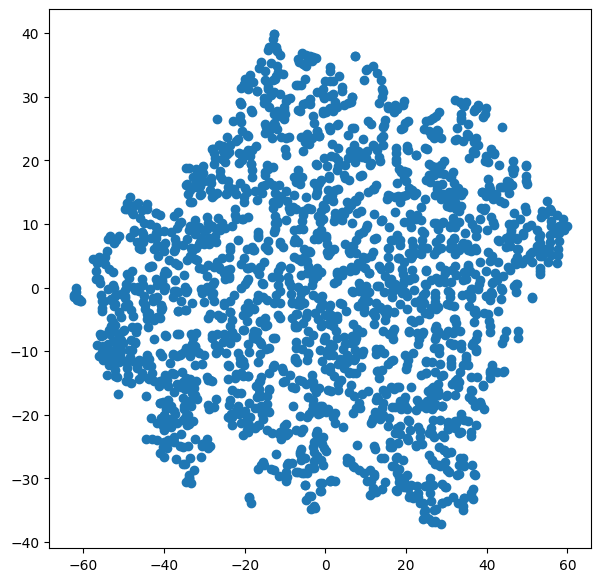

23


[22:54:36] WARNING: not removing hydrogen atom without neighbors


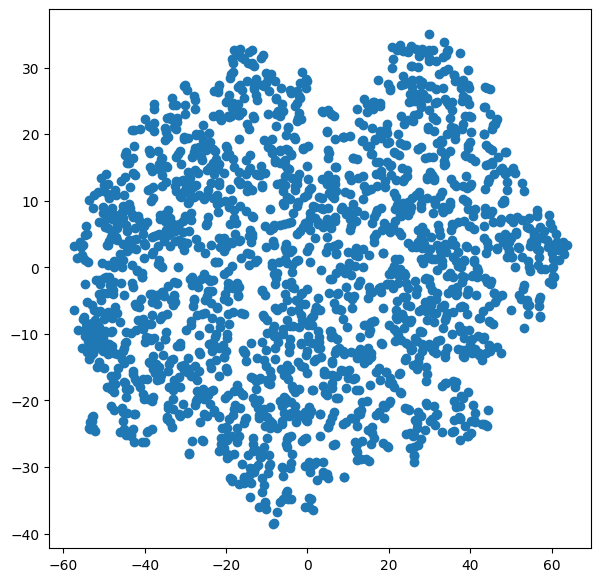

24


[22:54:38] WARNING: not removing hydrogen atom without neighbors


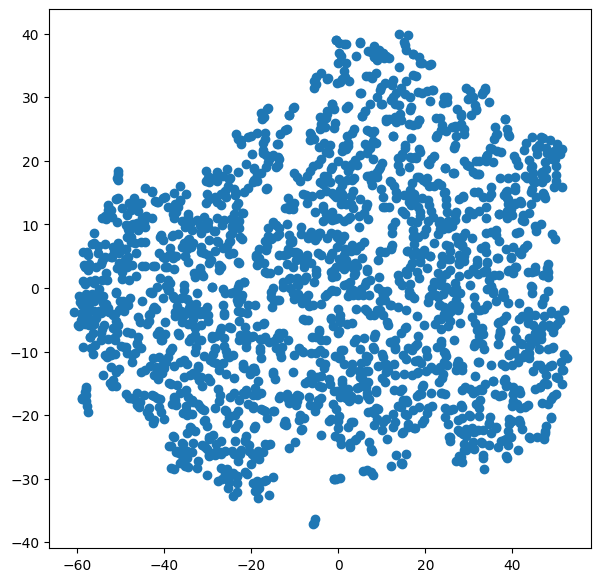

25


[22:54:41] WARNING: not removing hydrogen atom without neighbors


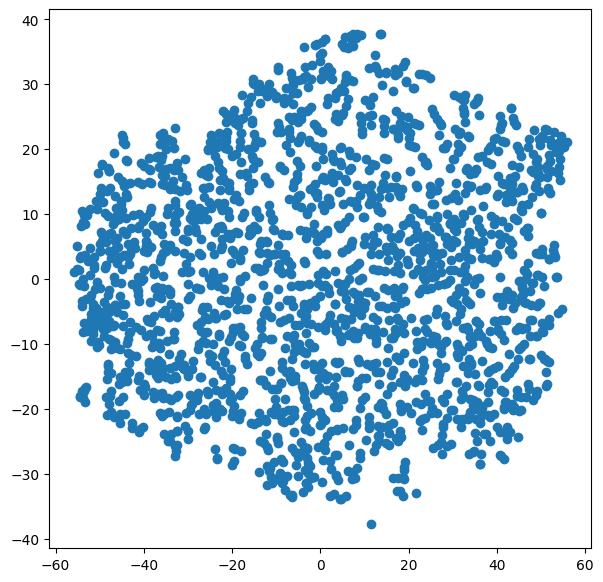

26


[22:54:43] WARNING: not removing hydrogen atom without neighbors


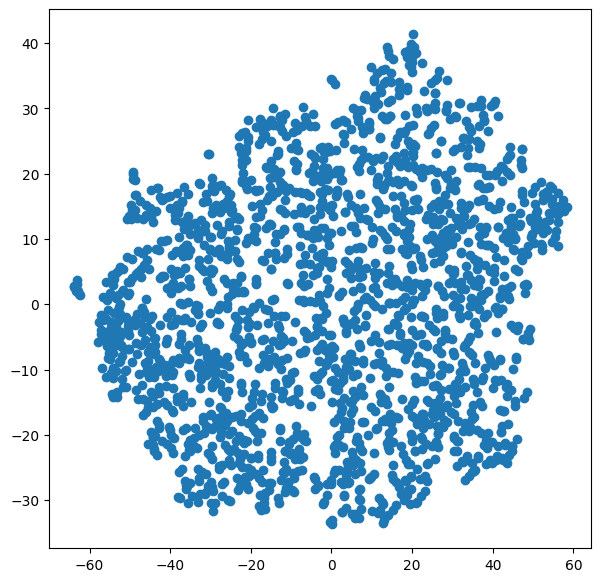

27


[22:54:45] WARNING: not removing hydrogen atom without neighbors


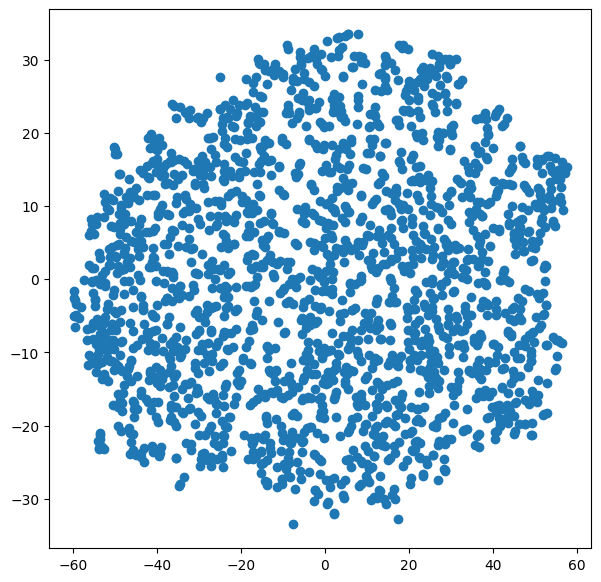

28


[22:54:46] WARNING: not removing hydrogen atom without neighbors


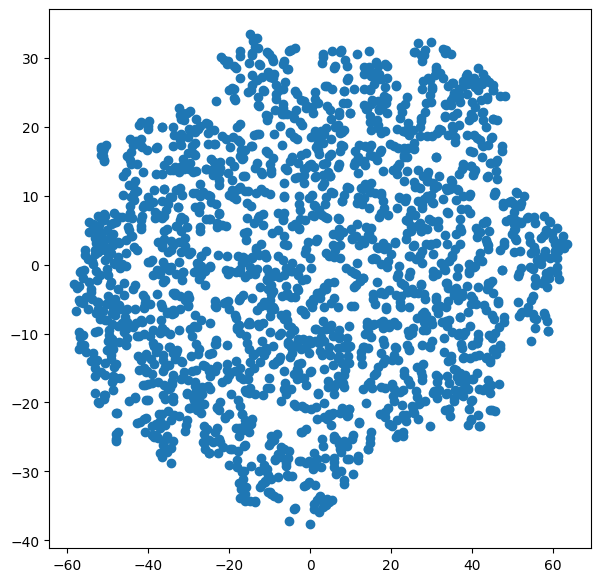

29


[22:54:49] WARNING: not removing hydrogen atom without neighbors


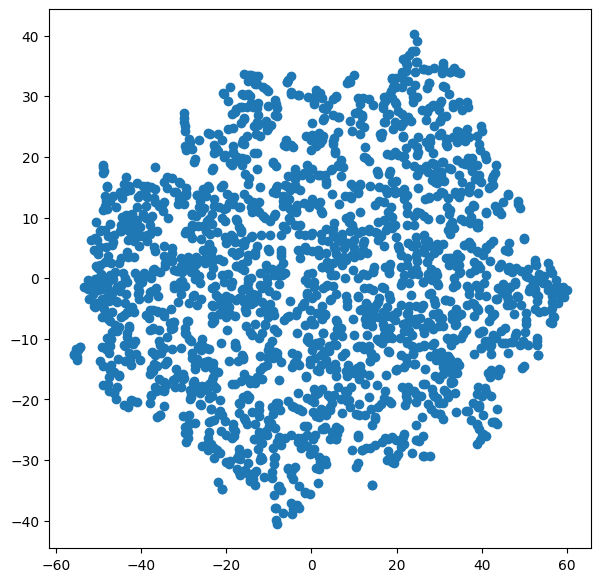

30


[22:54:51] WARNING: not removing hydrogen atom without neighbors


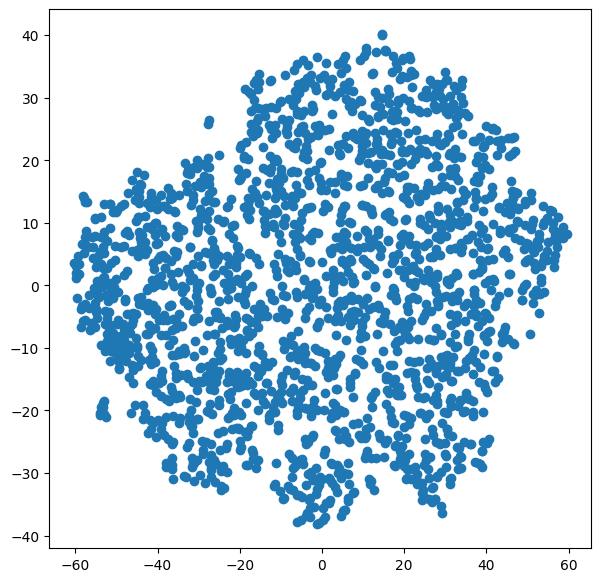

31


[22:54:53] WARNING: not removing hydrogen atom without neighbors


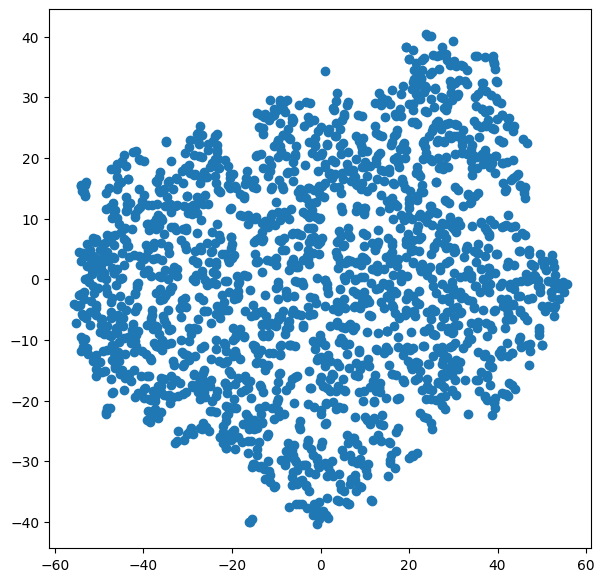

32


[22:54:55] WARNING: not removing hydrogen atom without neighbors


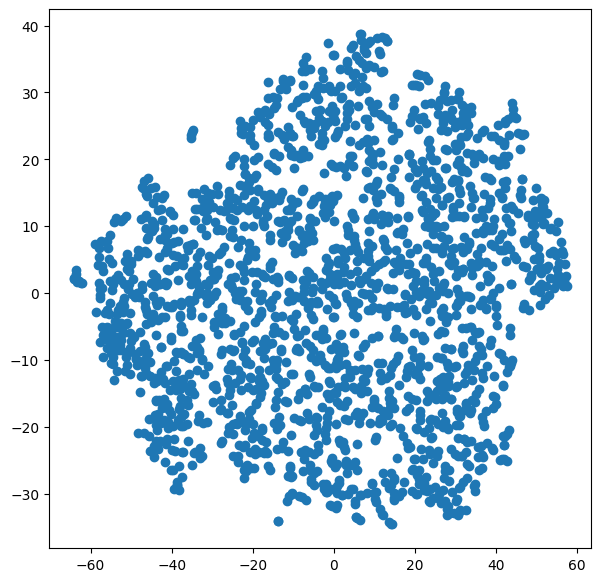

33


[22:54:57] WARNING: not removing hydrogen atom without neighbors


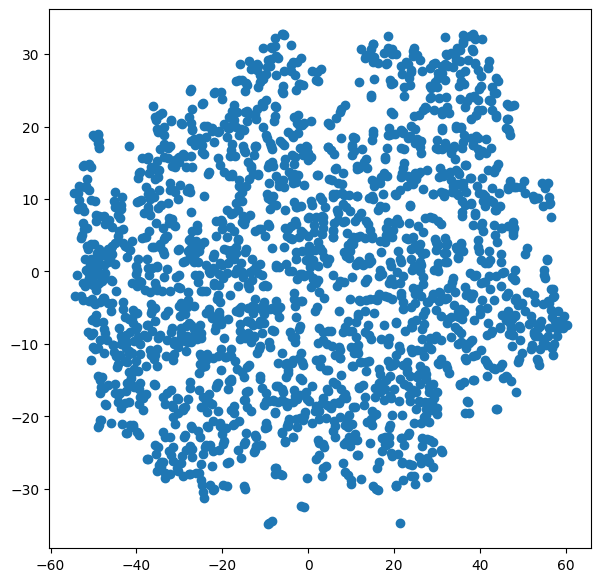

34


[22:54:59] WARNING: not removing hydrogen atom without neighbors


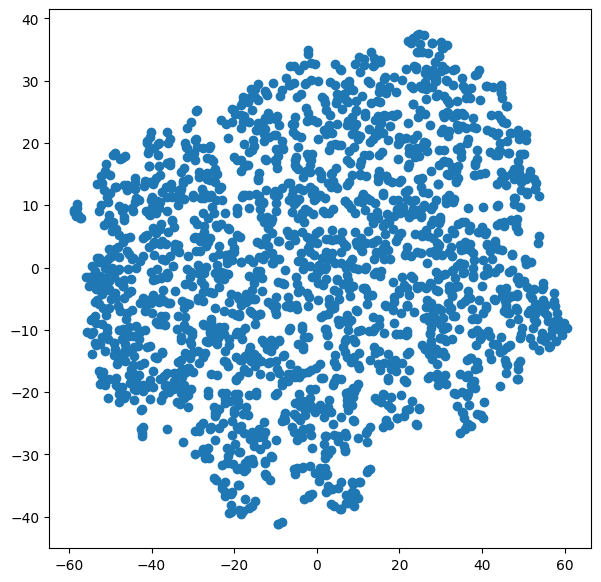

35


[22:55:02] WARNING: not removing hydrogen atom without neighbors


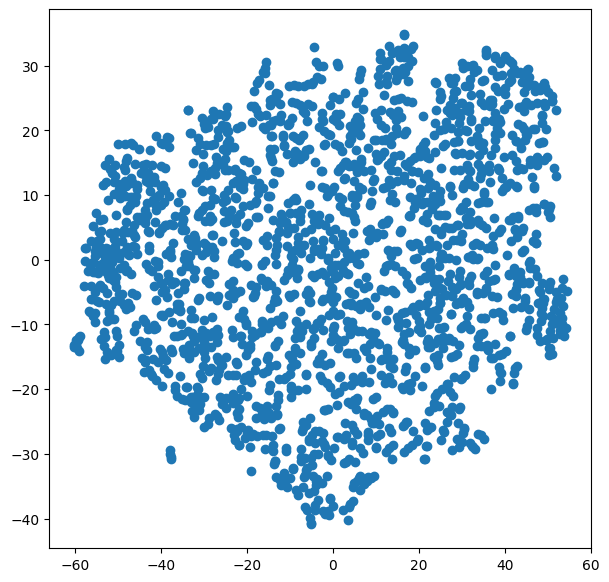

36


[22:55:04] WARNING: not removing hydrogen atom without neighbors


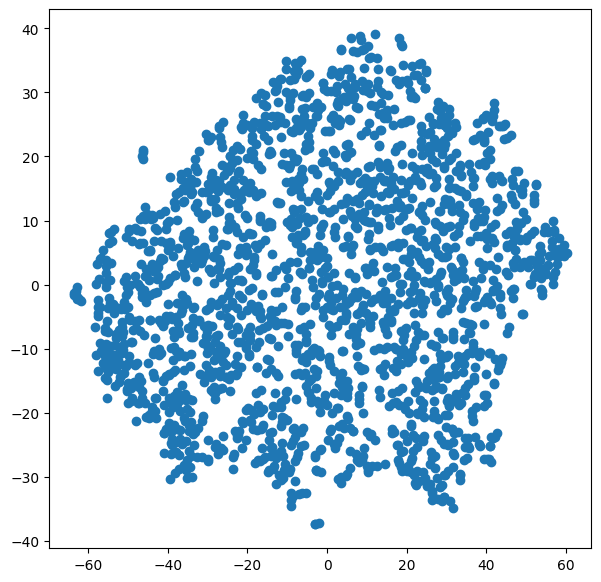

37


[22:55:06] WARNING: not removing hydrogen atom without neighbors


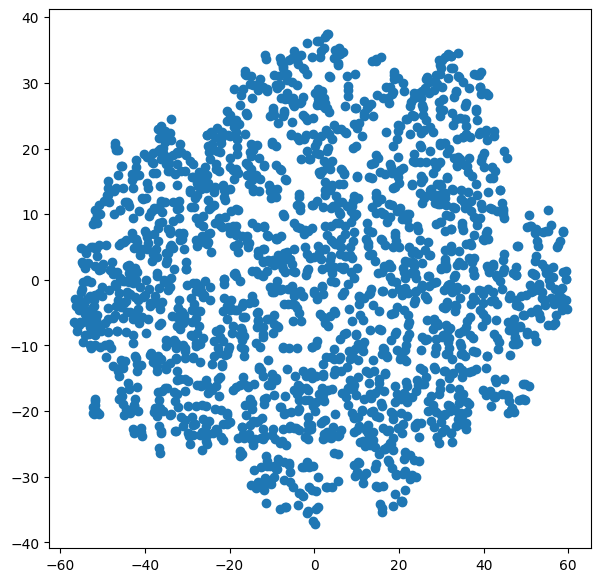

38


[22:55:08] WARNING: not removing hydrogen atom without neighbors


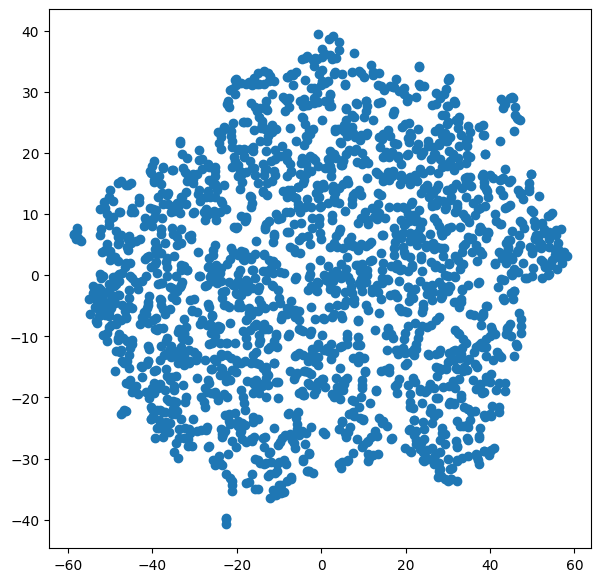

39


[22:55:10] WARNING: not removing hydrogen atom without neighbors


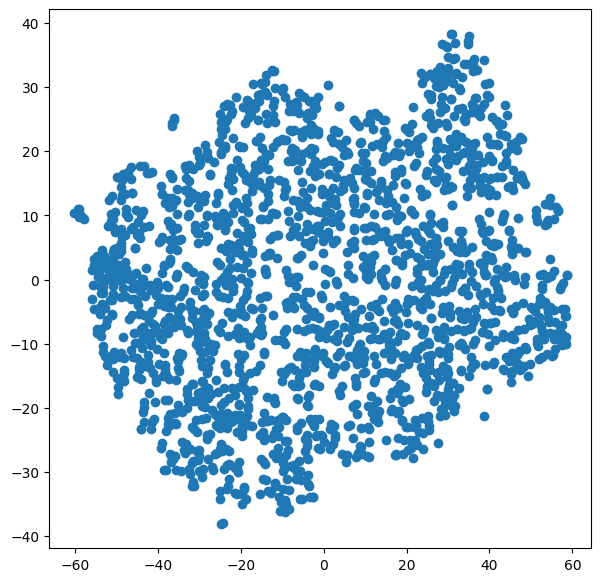

40


[22:55:12] WARNING: not removing hydrogen atom without neighbors


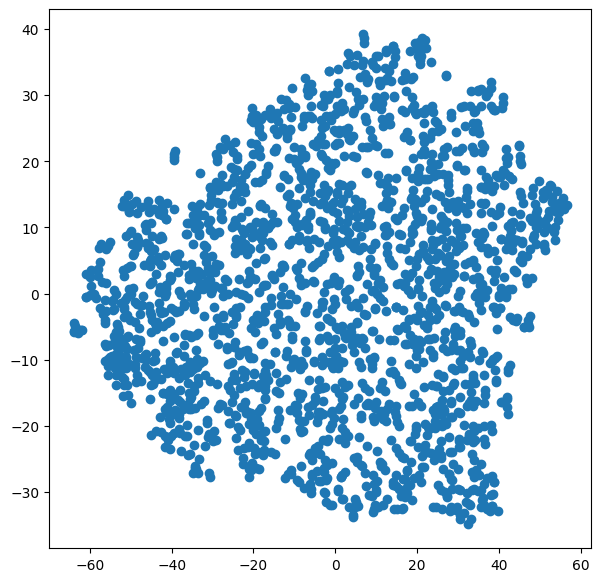

41


[22:55:14] WARNING: not removing hydrogen atom without neighbors


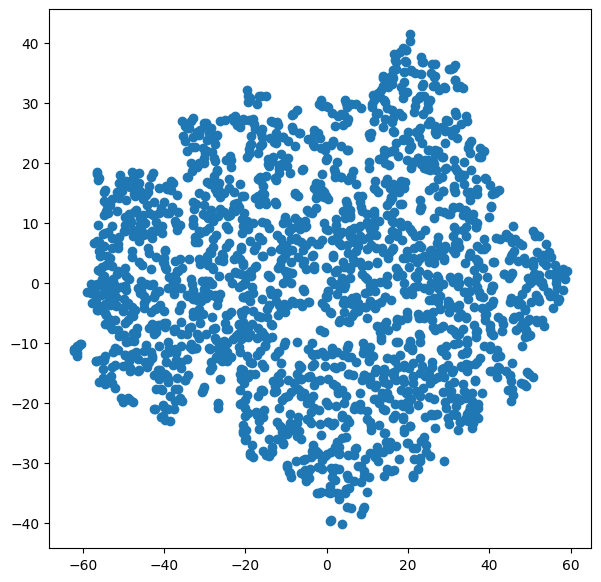

In [6]:
for i in range(42):
    print(i)
    y = []
    for smi in df["smiles"].tolist():
        mol = Chem.MolFromSmiles(smi)
        y.append(rdMolDescriptors.MQNs_(mol)[i])

    x_pc = TSNE(n_components=2).fit_transform(np.array(x))

    fig, ax = plt.subplots(figsize=(7, 7))

    # for i, coord in enumerate(x_pc):
    #     ax.text(coord[0], 
    #             coord[1], 
    #             str(y[i]), fontsize=18)

    ax.scatter(x_pc.T[0], x_pc.T[1])
    plt.show()